In [1]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [2]:
# we are using a pre-trained model
model = ResNet50(weights='imagenet')

In [27]:
# let's take an image of a pug/fig and test our model on it
img_path = 'static/images/fig.jpg' 
'''
# webp images are not supported by keras, so we need to convert it to jpg
from PIL import Image
img = Image.open(img_path).convert('RGB')
'''

"\n# webp images are not supported by keras, so we need to convert it to jpg\nfrom PIL import Image\nimg = Image.open(img_path).convert('RGB')\n"

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

[[[126 116 151]
  [121 111 146]
  [115 105 140]
  ...
  [ 21  28  57]
  [ 14  21  50]
  [ 12  19  48]]

 [[130 120 155]
  [126 116 151]
  [121 111 146]
  ...
  [ 25  32  61]
  [ 15  22  51]
  [ 10  17  46]]

 [[134 122 158]
  [132 120 156]
  [129 117 153]
  ...
  [ 32  39  68]
  [ 17  24  53]
  [  8  15  44]]

 ...

 [[ 12  15  34]
  [ 12  15  34]
  [ 12  15  34]
  ...
  [109  96 126]
  [108  95 125]
  [102  89 117]]

 [[ 13  16  35]
  [ 13  16  35]
  [ 13  16  35]
  ...
  [102  89 119]
  [110  97 127]
  [111  98 126]]

 [[ 13  16  35]
  [ 13  16  35]
  [ 13  16  35]
  ...
  [ 78  65  95]
  [ 99  86 116]
  [114 101 129]]]


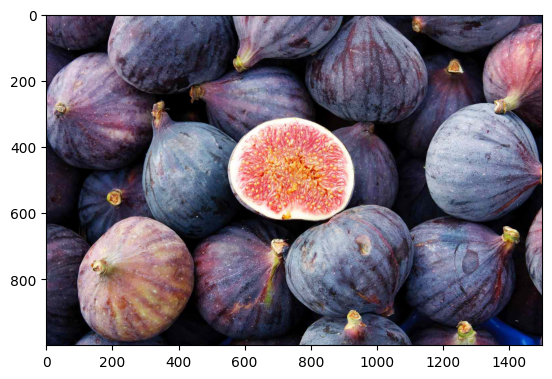

In [28]:
from skimage.io import imread # to read the image as a numpy array
print(imread(img_path)) # we can see that an image is just a matrix of RGB values
img = imread(img_path)
plt.imshow(img)

In [6]:
from PIL import Image

In [29]:
# prediction
image_file = keras.utils.load_img(img_path, target_size=(224, 224))
x = keras.utils.img_to_array(image_file)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


In [30]:
print('Predicted:', decode_predictions(preds, top=3)[0])

Predicted: [('n07753113', 'fig', np.float32(0.9998691)), ('n03127925', 'crate', np.float32(2.1171376e-05)), ('n03461385', 'grocery_store', np.float32(1.960493e-05))]


In [31]:
# prediction output
output = decode_predictions(preds, top=3)[0]
for i in output:
    print(i[1], ":", i[2]*100, "%")
# final output
print("-" * 50)
print("The image is most likely a {} with a {:.2f}% confidence.".format(output[0][1], output[0][2]*100))
print("==" * 30)

fig : 99.98691 %
crate : 0.0021171377 %
grocery_store : 0.001960493 %
--------------------------------------------------
The image is most likely a fig with a 99.99% confidence.
